# 1.0. Setup (RUN)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install mne mne-icalabel numpy scipy pandas matplotlib scikit-learn

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 10.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


# 1.1. Imports & Configuration (RUN)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import mne
from mne.preprocessing import ICA
from mne.time_frequency import psd_array_welch
from mne_icalabel import label_components

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

CSV_DIR = Path("/content/drive/MyDrive/ResearchData/Secondary")
OUT_DIR = Path("/content/drive/MyDrive/EEG_processed_auto")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_SFREQ = 128
CSV_UNIT_SCALE = 1e-6

SNR_TARGET_DB = 2.0
ENABLE_SNR_RESCUE = True
SNR_MAX_EPOCH_DROP_FRAC = 0.25
SNR_BAD_CH_DB = -2.5
SNR_MIN_KEEP_RATIO = 0.50



EEG_CHANNELS = [
    "AF3","AF4","F3","F4","F7","F8","FC5","FC6","T7","T8","P7","P8","O1","O2"
]

TARGET_SFREQ = 128
LINE_FREQ = 50
BANDPASS = (2.0, 30.0)

ICA_HP_FREQ = 1.0
ICA_NCOMP = 0.99
ICLABEL_THRESHOLD = 0.50
ARTIFACT_CLASSES = {"eye blink","muscle artifact","heart beat","line noise","channel noise"}

BADSEG_ZTHRESH = 6.0
BADSEG_MIN_DURATION = 0.20

MIN_KEEP_RATIO = 0.65
MAX_BAD_CH_TO_INTERP = 3
BADCH_FRAC_THRESH = 0.01

WIN_SEC = 8.0
OVERLAP_SEC = 4.0
STEP_SEC = WIN_SEC - OVERLAP_SEC

BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45),
}

# 2.0. Utility Functions (RUN)

In [3]:
def expected_epoch_count(raw, win_sec, step_sec):
    T = raw.times[-1]
    if T < win_sec:
        return 0
    return int(np.floor((T - win_sec) / step_sec) + 1)

def annotate_high_amplitude(raw_in, picks, z_thresh=8.0, min_duration=0.2, desc="BAD_amp"):
    """Robust high-amplitude detector using MAD; annotates contaminated time segments."""
    r = raw_in.copy().pick(picks=picks)
    data = r.get_data()

    med = np.median(data, axis=1, keepdims=True)
    mad = np.median(np.abs(data - med), axis=1, keepdims=True) + 1e-20

    z = np.max(np.abs((data - med) / mad), axis=0)
    bad = z > z_thresh

    times = r.times
    onsets, durations = [], []
    in_bad = False
    start_t = None

    for i, b in enumerate(bad):
        if b and not in_bad:
            in_bad = True
            start_t = times[i]
        elif (not b) and in_bad:
            in_bad = False
            end_t = times[i]
            if (end_t - start_t) >= min_duration:
                onsets.append(start_t)
                durations.append(end_t - start_t)

    if in_bad:
        end_t = times[-1]
        if (end_t - start_t) >= min_duration:
            onsets.append(start_t)
            durations.append(end_t - start_t)

    if len(onsets) > 0:
        ann = mne.Annotations(onsets, durations, [desc] * len(onsets))
        raw_in.set_annotations(raw_in.annotations + ann)

    return raw_in

def noisy_channel_scores(raw_in, picks, z_thresh=8.0):
    """
    Score channels by fraction of samples exceeding robust z-threshold.
    Higher fraction = noisier channel.
    """
    r = raw_in.copy().pick(picks=picks)
    data = r.get_data()
    med = np.median(data, axis=1, keepdims=True)
    mad = np.median(np.abs(data - med), axis=1, keepdims=True) + 1e-20
    z = np.abs((data - med) / mad)  # (n_ch, n_times)
    frac = np.mean(z > z_thresh, axis=1)
    return dict(zip(r.ch_names, frac))

def make_epochs_clean(raw_in):
    """Create fixed-length epochs with reject_by_annotation."""
    epochs = mne.make_fixed_length_epochs(
        raw_in, duration=WIN_SEC, overlap=OVERLAP_SEC,
        preload=True, reject_by_annotation=True
    )
    return epochs

def ensure_montage_available(raw_in):
    """
    Interpolation needs channel positions. In EEGLAB .set, these often exist.
    This function checks montage/dig and raises a clear error if missing.
    """
    montage = raw_in.get_montage()
    if montage is not None:
        return True

    loc_ok = True
    for ch in raw_in.info["chs"]:
        loc = ch["loc"][:3]
        if np.allclose(loc, 0) or np.any(~np.isfinite(loc)):
            loc_ok = False
            break

    if not loc_ok:
        return False
    return True

def load_csv_as_raw(
    csv_path,
    ch_order,
    sfreq_default=128,
    unit_scale=1e-6,
    montage_name="standard_1020",
):
    """Load a 14‑channel EEG CSV into an MNE Raw object.

    Expected format: one column per channel, one row per sample.
    - If a time/timestamp column exists, sfreq is inferred from it.
    - Otherwise sfreq_default is used.
    - Values are scaled by unit_scale (set to 1.0 if already in volts).
    """
    df = pd.read_csv(csv_path)

    time_col = None
    for c in ["time", "Time", "timestamp", "Timestamp", "t", "T"]:
        if c in df.columns:
            time_col = c
            break

    sfreq = sfreq_default
    if time_col is not None:
        t = pd.to_numeric(df[time_col], errors="coerce").to_numpy()
        t = t[np.isfinite(t)]
        if len(t) >= 2:
            dt = np.median(np.diff(t))
            if np.isfinite(dt) and dt > 0:
                sfreq = float(1.0 / dt)
        df = df.drop(columns=[time_col])

    col_map = {c.upper(): c for c in df.columns}
    missing = [ch for ch in ch_order if ch.upper() not in col_map]
    if missing and df.shape[1] == len(ch_order):
        df = df.iloc[:, :len(ch_order)].copy()
        df.columns = ch_order
        col_map = {c.upper(): c for c in df.columns}
        missing = [ch for ch in ch_order if ch.upper() not in col_map]
    if missing:
        raise ValueError(
            f"Missing channels in {Path(csv_path).name}: {missing}. "
            f"Found columns: {list(df.columns)}"
        )

    ordered_cols = [col_map[ch.upper()] for ch in ch_order]

    data = df[ordered_cols].apply(pd.to_numeric, errors="coerce").to_numpy()
    if np.isnan(data).any():
        data = (
            pd.DataFrame(data)
            .interpolate(limit_direction="both")
            .ffill()
            .bfill()
            .fillna(0.0)
            .to_numpy()
        )

    data = (data.T * unit_scale).astype(np.float64)

    info = mne.create_info(ch_names=ch_order, sfreq=sfreq, ch_types=["eeg"] * len(ch_order))
    raw = mne.io.RawArray(data, info, verbose="ERROR")

    montage = mne.channels.make_standard_montage(montage_name)
    raw.set_montage(montage, match_case=False, on_missing="ignore")

    return raw

def fit_ica_safe(
    raw_for_ica,
    n_components,
    method="fastica",
    random_state=42,
    max_iter="auto",
    verbose=True,
):
    """Fit ICA with a robust fallback.

    Why this exists:
      - In MNE, ICA(n_components=<float>) uses PCA to keep enough components to
        explain that fraction of variance.
      - If the FIRST PC already explains >= that fraction (e.g., 99%),
        MNE ends up with 1 PCA component and raises:
        '... your threshold results in 1 component ...'

    Fallback behavior:
      - If that specific error happens, retry with an integer number of
        components (typically n_channels - 1 after average referencing),
        but at least 2.

    Returns
    -------
    ica : mne.preprocessing.ICA
    used_n_components : float|int
        The value actually used to fit ICA.
    """
    try:
        ica = ICA(
            n_components=n_components,
            method=method,
            random_state=random_state,
            max_iter=max_iter,
        )
        ica.fit(raw_for_ica)
        return ica, n_components
    except RuntimeError as e:
        msg = str(e)
        if ("threshold results in 1 component" in msg) or ("results in 1 component" in msg):
            nchan = len(raw_for_ica.ch_names)
            fallback = max(2, nchan - 1)
            fallback = min(fallback, nchan)

            if verbose:
                print("⚠️ ICA fallback triggered:")
                print(msg)
                print(f"Retrying ICA with n_components={fallback} (instead of {n_components})")

            ica = ICA(
                n_components=fallback,
                method=method,
                random_state=random_state,
                max_iter=max_iter,
            )
            ica.fit(raw_for_ica)
            return ica, fallback
        raise


# 3.0. Load .csv (RUN)

In [9]:
csv_files = sorted(CSV_DIR.glob("*.csv"))
if len(csv_files) == 0:
    raise FileNotFoundError(f"No .csv files found in: {CSV_DIR}")

FILE_INDEX = 21
set_path = csv_files[FILE_INDEX]
print("Loading:", set_path.name)

raw = load_csv_as_raw(
    set_path,
    ch_order=EEG_CHANNELS,
    sfreq_default=CSV_SFREQ,
    unit_scale=CSV_UNIT_SCALE,
    montage_name="standard_1020",
)
raw.pick(picks="eeg")

print(raw)
print("Channels kept:", raw.ch_names)
print("sfreq:", raw.info["sfreq"])

raw_before = raw.copy()


Loading: S11LO.csv
<RawArray | 14 x 19200 (150.0 s), ~2.1 MiB, data loaded>
Channels kept: ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
sfreq: 128.0


# 4.0. Preprocessing (RUN)

In [10]:
raw.resample(TARGET_SFREQ)
raw.notch_filter(freqs=[LINE_FREQ], picks="eeg")
raw.filter(l_freq=BANDPASS[0], h_freq=BANDPASS[1], picks="eeg")
raw.set_eeg_reference("average", projection=False)

print("Preprocessing done. sfreq =", raw.info["sfreq"])

Sampling frequency of the instance is already 128.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 845 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 2 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition 

# 5.0. Automatic ICA (ICLabel) Artifact Removal (RUN)

In [11]:
raw_for_ica = raw.copy().filter(l_freq=ICA_HP_FREQ, h_freq=None, picks="eeg")

ica, used_ncomp = fit_ica_safe(raw_for_ica, ICA_NCOMP, method="fastica", random_state=42, max_iter="auto")
print("ICA n_components used:", used_ncomp)

labels = label_components(raw, ica, method="iclabel")
ic_labels = labels["labels"]
ic_proba  = labels["y_pred_proba"]

exclude = []
for i, lab in enumerate(ic_labels):
    conf = float(ic_proba[i].max())
    if (lab in ARTIFACT_CLASSES) and (conf >= ICLABEL_THRESHOLD):
        exclude.append(i)

ica.exclude = exclude
print("Auto-excluding ICA components:", ica.exclude)
print("Counts by label:", Counter([ic_labels[i] for i in ica.exclude]))

raw_ica = ica.apply(raw.copy())

fif_path = OUT_DIR / f"{set_path.stem}_clean_raw_ICA.fif"
raw_ica.save(fif_path, overwrite=True)
print("Saved:", fif_path)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 423 samples (3.305 s)

Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by explained variance: 13 components
Fitting ICA took 2.0s.
ICA n_components used: 0.99


/tmp/ipykernel_9257/304102247.py:6: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/tmp/ipykernel_9257/304102247.py:6: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  labels = label_components(raw, ica, method="iclabel")


Auto-excluding ICA components: [1, 4]
Counts by label: Counter({'eye blink': 2})
Applying ICA to Raw instance
    Transforming to ICA space (13 components)
    Zeroing out 2 ICA components
    Projecting back using 14 PCA components
Overwriting existing file.
Writing /content/drive/MyDrive/EEG_processed_auto/S11LO_clean_raw_ICA.fif
Overwriting existing file.


/tmp/ipykernel_9257/304102247.py:23: RuntimeWarning: This filename (/content/drive/MyDrive/EEG_processed_auto/S11LO_clean_raw_ICA.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_ica.save(fif_path, overwrite=True)


Closing /content/drive/MyDrive/EEG_processed_auto/S11LO_clean_raw_ICA.fif
[done]
Saved: /content/drive/MyDrive/EEG_processed_auto/S11LO_clean_raw_ICA.fif


# 6.0. Bad Segment Annotation + Adaptive Interpolation (RUN)

In [12]:
raw_work = raw_ica.copy()
raw_work = annotate_high_amplitude(
    raw_work,
    picks=raw_work.ch_names,
    z_thresh=BADSEG_ZTHRESH,
    min_duration=BADSEG_MIN_DURATION,
    desc="BAD_amp"
)

epochs_0 = make_epochs_clean(raw_work)

expected = expected_epoch_count(raw_work, WIN_SEC, STEP_SEC)
kept = len(epochs_0)
keep_ratio = kept / expected if expected > 0 else 0

print(f"Expected epochs: {expected}")
print(f"Kept epochs    : {kept}")
print(f"Keep ratio     : {keep_ratio:.2f}")

do_interp = (keep_ratio < MIN_KEEP_RATIO)

if do_interp:
    print("\nTRIGGER: Too many epochs dropped -> auto-detect noisy channels and interpolate.\n")

    scores = noisy_channel_scores(raw_ica, picks=raw_ica.ch_names, z_thresh=BADSEG_ZTHRESH)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    print("Noisy channel scores (fraction above z-threshold):")
    for ch, sc in ranked:
        print(f"{ch:>6s} : {sc:.4f}")

    bad_candidates = [ch for ch, sc in ranked if sc >= BADCH_FRAC_THRESH]
    bad_to_interp = bad_candidates[:MAX_BAD_CH_TO_INTERP]

    if len(bad_to_interp) == 0:
        print("\nNo channels exceeded BADCH_FRAC_THRESH; skipping interpolation.\n")
        raw_final = raw_work
        epochs_final = epochs_0
    else:
        print("\nAuto-marking bad channels for interpolation:", bad_to_interp)

        if not ensure_montage_available(raw_ica):
            raise RuntimeError(
                "Interpolation requires channel locations/montage, but none were found. "
                "Ensure your .set has channel locations, or provide montage before interpolation."
            )

        raw_interp = raw_ica.copy()
        raw_interp.info["bads"] = bad_to_interp
        raw_interp.interpolate_bads(reset_bads=True)

        raw_interp = annotate_high_amplitude(
            raw_interp,
            picks=raw_interp.ch_names,
            z_thresh=BADSEG_ZTHRESH,
            min_duration=BADSEG_MIN_DURATION,
            desc="BAD_amp"
        )

        epochs_1 = make_epochs_clean(raw_interp)

        expected1 = expected_epoch_count(raw_interp, WIN_SEC, STEP_SEC)
        kept1 = len(epochs_1)
        keep_ratio1 = kept1 / expected1 if expected1 > 0 else 0

        print(f"\nAfter interpolation:")
        print(f"Expected epochs: {expected1}")
        print(f"Kept epochs    : {kept1}")
        print(f"Keep ratio     : {keep_ratio1:.2f}")

        raw_final = raw_interp
        epochs_final = epochs_1
else:
    print("\nNo interpolation needed; keep ratio acceptable.\n")
    raw_final = raw_work
    epochs_final = epochs_0

print("\nFinal channels:", raw_final.ch_names)
print("Final epochs:", len(epochs_final))

Not setting metadata
36 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 36 events and 1024 original time points ...
18 bad epochs dropped
Expected epochs: 36
Kept epochs    : 18
Keep ratio     : 0.50

TRIGGER: Too many epochs dropped -> auto-detect noisy channels and interpolate.

Noisy channel scores (fraction above z-threshold):
    F4 : 0.0368
   FC6 : 0.0224
    O1 : 0.0159
    P7 : 0.0107
    F3 : 0.0095
    F7 : 0.0083
    O2 : 0.0081
    T7 : 0.0072
    F8 : 0.0069
    P8 : 0.0056
   FC5 : 0.0048
   AF3 : 0.0034
   AF4 : 0.0021
    T8 : 0.0017

Auto-marking bad channels for interpolation: ['F4', 'FC6', 'O1']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 94.1 mm
Computing interpolation matrix from 11 sensor positions
Interpolating 3 sensors
Not setting metadata
36 matching events found
No baseline correction applied
0 projection ite

In [13]:
def epoch_band_snr_db(
    epochs,
    signal_band=(8, 30),
    noise_bands=((0.5, 2), (48, 52)),
    fmin=0.5,
    fmax=60.0,
    return_epochwise=False,
):
    """Bandpower SNR (dB) per channel, optionally per-epoch.

    Uses a *relative* numerical floor (eps) so results are stable even if the input data
    are scaled (e.g., already in Volts vs µV), avoiding the 'all ~0 dB' artifact caused by
    a hard-coded epsilon.
    """
    psd = epochs.compute_psd(fmin=fmin, fmax=fmax)
    psds, freqs = psd.get_data(return_freqs=True)

    def bp(a, b):
        idx = (freqs >= a) & (freqs < b)
        if not np.any(idx):
            return np.zeros(psds.shape[:2])
        return np.trapz(psds[:, :, idx], freqs[idx], axis=2)

    sig = bp(signal_band[0], signal_band[1])
    noi = np.zeros_like(sig)
    for a, b in noise_bands:
        a2 = max(a, fmin)
        b2 = min(b, fmax)
        if b2 > a2:
            noi += bp(a2, b2)

    scale = float(np.nanmedian(psds))
    eps = max(scale * 1e-12, np.finfo(float).tiny)

    snr = 10.0 * np.log10((sig + eps) / (noi + eps))

    if return_epochwise:
        return epochs.ch_names, snr
    return epochs.ch_names, snr.mean(axis=0)

def drop_low_snr_epochs(
    epochs_in,
    target_db=SNR_TARGET_DB,
    max_drop_frac=SNR_MAX_EPOCH_DROP_FRAC,
    min_keep_ratio=SNR_MIN_KEEP_RATIO,
):
    """Drop worst epochs (by mean SNR across channels) until reaching target or limits."""
    if len(epochs_in) == 0:
        return epochs_in, []

    chs, snr_mat = epoch_band_snr_db(epochs_in, return_epochwise=True)
    snr_epoch = snr_mat.mean(axis=1)

    n = len(epochs_in)
    max_drop = int(np.floor(n * max_drop_frac))
    min_keep = int(np.ceil(n * min_keep_ratio))
    max_drop = min(max_drop, n - min_keep)

    order = np.argsort(snr_epoch)
    keep_mask = np.ones(n, dtype=bool)

    dropped = 0
    while dropped < max_drop and float(np.mean(snr_epoch[keep_mask])) < float(target_db):
        keep_mask[order[dropped]] = False
        dropped += 1

    drop_idx = np.where(~keep_mask)[0].tolist()
    epochs_out = epochs_in.copy()
    if len(drop_idx) > 0:

        epochs_out.drop(sorted(drop_idx, reverse=True), reason="low_snr")

    return epochs_out, drop_idx

try:
    ch_fin0, snr_fin0 = epoch_band_snr_db(epochs_final)
    avg_snr0 = float(np.mean(snr_fin0)) if len(snr_fin0) else float("nan")
except Exception as e:
    print("SNR rescue skipped (PSD/SNR computation failed):", repr(e))
    avg_snr0 = None

if (ENABLE_SNR_RESCUE is True) and (avg_snr0 is not None) and (not np.isnan(avg_snr0)) and (avg_snr0 < SNR_TARGET_DB):
    print("\n[SNR RESCUE] Triggered.")
    print(f"[SNR RESCUE] Current average SNR = {avg_snr0:.2f} dB, target = {SNR_TARGET_DB:.2f} dB")

    snr_df0 = pd.DataFrame({"channel": ch_fin0, "snr": snr_fin0}).sort_values("snr")
    bad_by_snr = snr_df0[snr_df0["snr"] < SNR_BAD_CH_DB]["channel"].tolist()

    if len(bad_by_snr) > 0:
        bad_by_snr = bad_by_snr[:MAX_BAD_CH_TO_INTERP]
        print("[SNR RESCUE] Interpolating low-SNR channels:", bad_by_snr)
        raw_final.info["bads"] = bad_by_snr
        raw_final.interpolate_bads(reset_bads=True)

        raw_final = annotate_high_amplitude(
            raw_final,
            picks=raw_final.ch_names,
            z_thresh=BADSEG_ZTHRESH,
            min_duration=BADSEG_MIN_DURATION,
            desc="BAD_amp",
        )
        epochs_final = make_epochs_clean(raw_final)

    epochs_before = len(epochs_final)
    epochs_final, dropped_idx = drop_low_snr_epochs(epochs_final)
    epochs_after = len(epochs_final)

    if len(dropped_idx) > 0:
        print(f"[SNR RESCUE] Dropped {len(dropped_idx)} / {epochs_before} epochs ({len(dropped_idx)/max(epochs_before,1):.1%})")

    ch_fin1, snr_fin1 = epoch_band_snr_db(epochs_final)
    avg_snr1 = float(np.mean(snr_fin1)) if len(snr_fin1) else float("nan")
    print(f"[SNR RESCUE] New average SNR = {avg_snr1:.2f} dB")

    if np.isnan(avg_snr1) or (avg_snr1 < SNR_TARGET_DB):
        print("[SNR RESCUE] WARNING: Could not reach the target within drop/interp limits.")
        print("             Consider relaxing the target, or expect some segments to remain < target.")
else:
    if ENABLE_SNR_RESCUE:
        print("\n[SNR RESCUE] Not triggered (SNR already >= target OR SNR unavailable).")
    else:
        print("\n[SNR RESCUE] Disabled.")

    Using multitaper spectrum estimation with 7 DPSS windows

[SNR RESCUE] Not triggered (SNR already >= target OR SNR unavailable).


/tmp/ipykernel_9257/3169727145.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psds[:, :, idx], freqs[idx], axis=2)


# 6.1. Interpolation Decision Report (RUN)

In [14]:
interp_used = False
interp_channels = []
keep_ratio_before = keep_ratio
keep_ratio_after = keep_ratio

if do_interp and "raw_interp" in locals():
    interp_used = True
    interp_channels = bad_to_interp
    keep_ratio_after = keep_ratio1

print("\n================= INTERPOLATION REPORT =================")
print("Interpolation used?:", interp_used)
print("Interpolated channels:", interp_channels if interp_used else "None")
print(f"Keep ratio before interpolation: {keep_ratio_before:.2f}")
print(f"Keep ratio after  interpolation: {keep_ratio_after:.2f}")
print("Final channel count:", len(raw_final.ch_names))
print("========================================================\n")

report = {
    "subject_file": set_path.name,
    "interpolation_used": interp_used,
    "interpolated_channels": ",".join(interp_channels),
    "expected_epochs": expected,
    "kept_epochs_before": kept,
    "keep_ratio_before": keep_ratio_before,
    "kept_epochs_after": len(epochs_final),
    "keep_ratio_after": keep_ratio_after,
}
report_path = OUT_DIR / f"{set_path.stem}_cleaning_report.csv"
pd.DataFrame([report]).to_csv(report_path, index=False)
print("Saved report:", report_path)


================= INTERPOLATION REPORT =================
Interpolation used?: True
Interpolated channels: ['F4', 'FC6', 'O1']
Keep ratio before interpolation: 0.50
Keep ratio after  interpolation: 0.83
Final channel count: 14

Saved report: /content/drive/MyDrive/EEG_processed_auto/S11LO_cleaning_report.csv


# 7.0. Feature Extraction (Welch PSD + Bandpower) (RUN)

In [15]:
data = epochs_final.get_data()
sfreq = epochs_final.info["sfreq"]
n_fft = int(WIN_SEC * sfreq)

psds, freqs = psd_array_welch(
    data, sfreq=sfreq, fmin=0.5, fmax=45, n_fft=n_fft, verbose=False
)

features = {}
for band, (fmin, fmax) in BANDS.items():
    idx = (freqs >= fmin) & (freqs < fmax)
    bp = np.trapezoid(psds[..., idx], freqs[idx], axis=-1)
    for ci, ch in enumerate(epochs_final.ch_names):
        features[f"{ch}_{band}"] = bp[:, ci]

df_feat = pd.DataFrame(features)

scaler = StandardScaler()
df_feat_z = pd.DataFrame(scaler.fit_transform(df_feat), columns=df_feat.columns)

feat_csv = OUT_DIR / f"{set_path.stem}_features_bandpower_z.csv"
df_feat_z.to_csv(feat_csv, index=False)
print("Saved features:", feat_csv)
print("Feature shape:", df_feat_z.shape)

Saved features: /content/drive/MyDrive/EEG_processed_auto/S11LO_features_bandpower_z.csv
Feature shape: (30, 70)


#VIS-1. PSD (After Cleaning) (RUN)

Setting 158 of 19200 (0.82%) samples to NaN, retaining 19042 (99.18%) samples.
Effective window size : 16.000 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).


/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:292: UserWarning: nperseg = 2048 is greater than input length  = 1, using nperseg = 1
  return _func(*args, **kwargs)


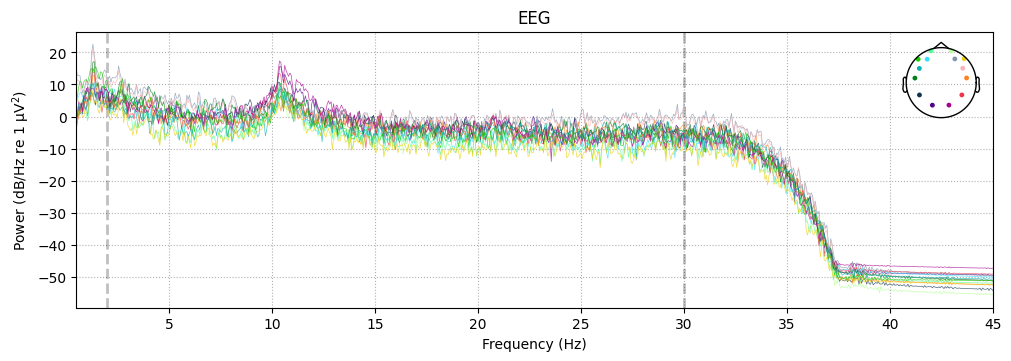

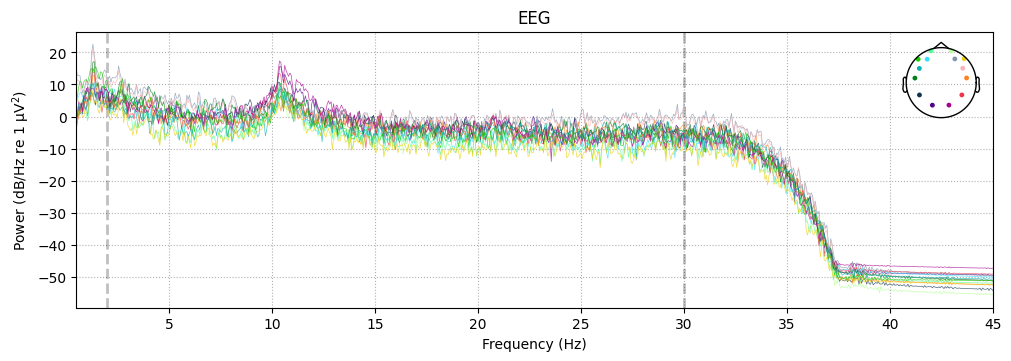

In [16]:
# ============================================================
# VIS 1 — PSD (After Cleaning) (RUN)
# ============================================================
raw_final.compute_psd(fmin=0.5, fmax=45).plot()

#VIS-2. Channel-wise Mean Bandpower (Theta/Alpha/Beta) (RUN)

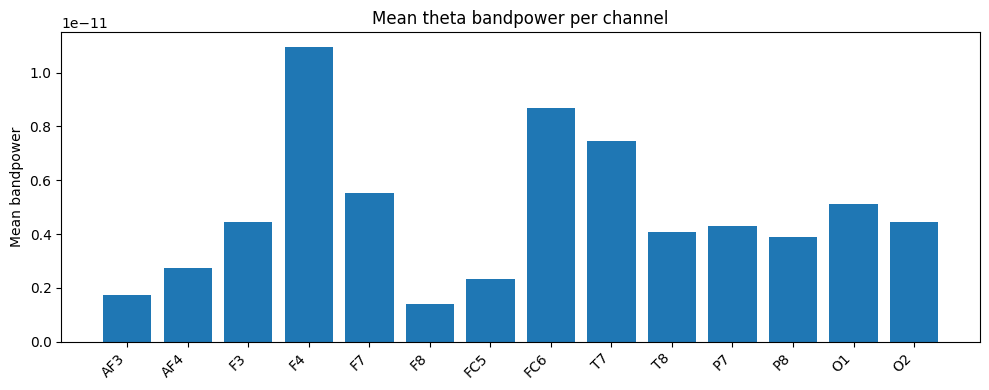

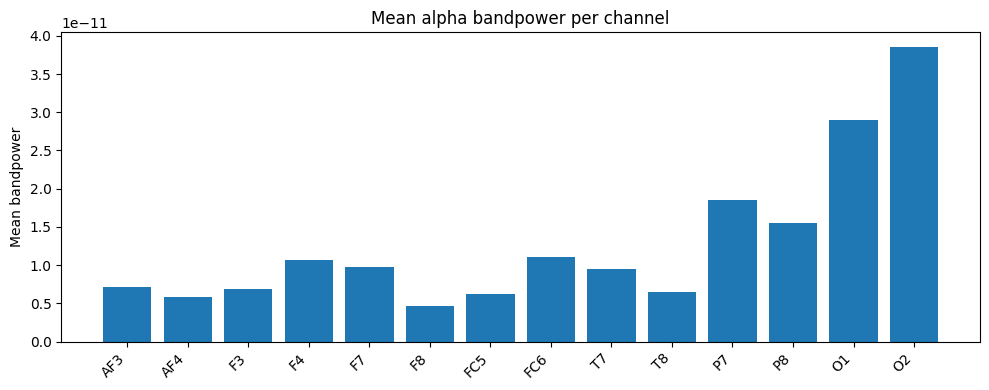

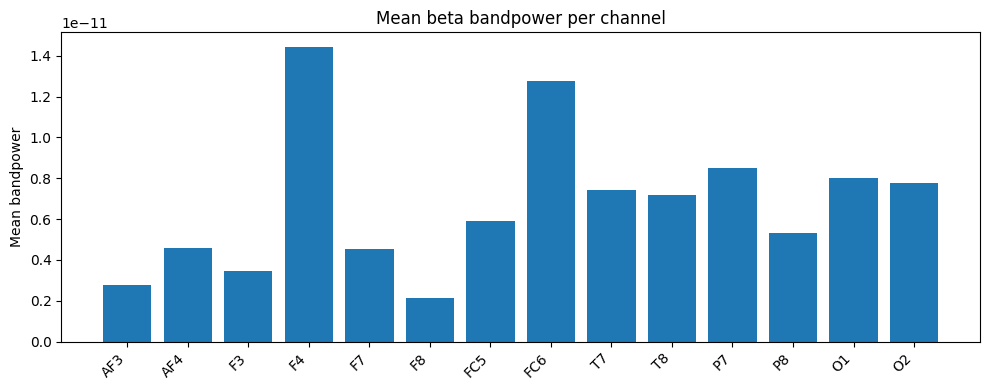

In [17]:
# ============================================================
# VIS 2 — Channel-wise Mean Bandpower (Theta/Alpha/Beta) (RUN)
# ============================================================
channels = epochs_final.ch_names
for band in ["theta", "alpha", "beta"]:
    cols = [f"{ch}_{band}" for ch in channels if f"{ch}_{band}" in df_feat.columns]
    means = df_feat[cols].mean()

    plt.figure(figsize=(10, 4))
    plt.bar([c.split("_")[0] for c in cols], means.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean bandpower")
    plt.title(f"Mean {band} bandpower per channel")
    plt.tight_layout()
    plt.show()

#VIS-3. Bandpower Over Time (Example) (RUN)

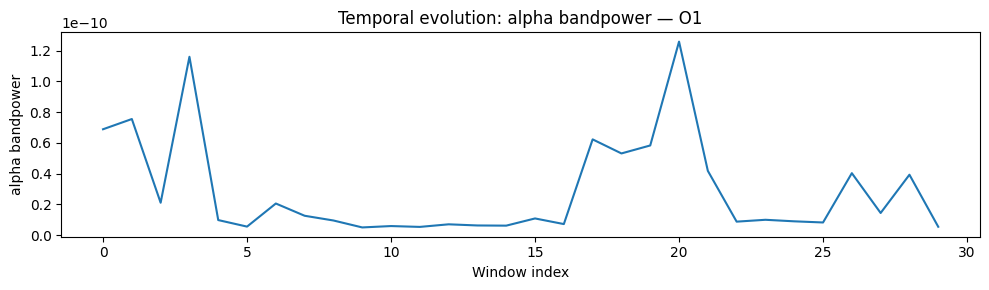

In [18]:
# ============================================================
# VIS 3 — Bandpower Over Time (Example) (RUN)
# ============================================================
example_ch = "O1" if "O1" in channels else channels[0]
example_band = "alpha"
colname = f"{example_ch}_{example_band}"

plt.figure(figsize=(10, 3))
plt.plot(df_feat[colname].values)
plt.xlabel("Window index")
plt.ylabel(f"{example_band} bandpower")
plt.title(f"Temporal evolution: {example_band} bandpower — {example_ch}")
plt.tight_layout()
plt.show()

#VIS-4. Feature Correlation Heatmap (RUN)

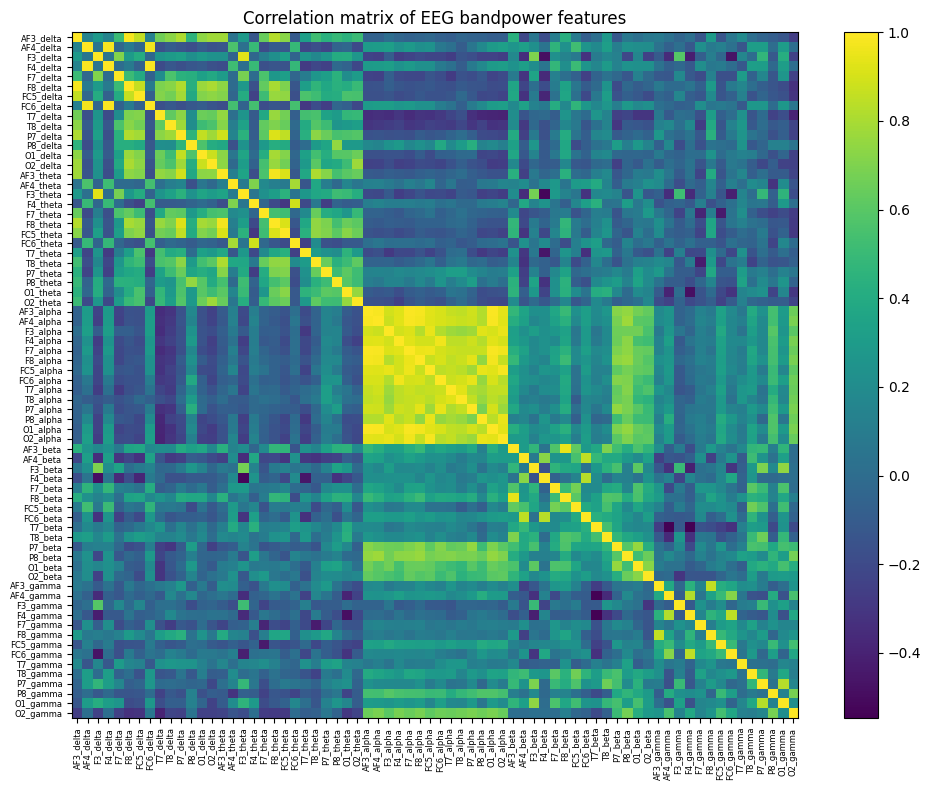

In [19]:
# ============================================================
# VIS 4 — Feature Correlation Heatmap (RUN)
# ============================================================
corr = df_feat.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.title("Correlation matrix of EEG bandpower features")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)
plt.tight_layout()
plt.show()

#VIS-5. PCA (RUN)

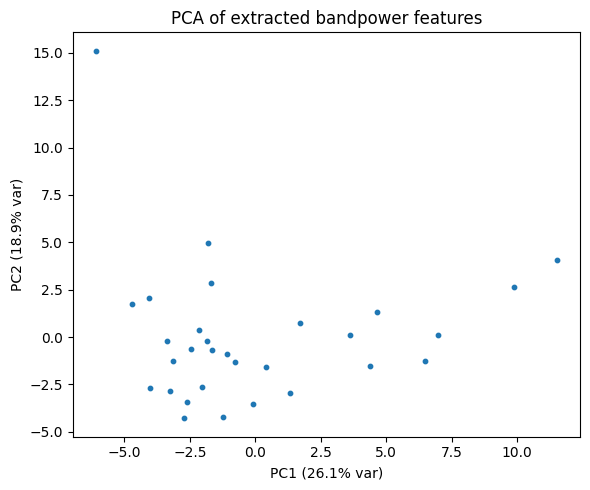

In [20]:
# ============================================================
# VIS 5 — PCA (RUN)
# ============================================================
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(df_feat_z.values)

plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], s=10)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of extracted bandpower features")
plt.tight_layout()
plt.show()

# VIS-6. SNR INFO (RUN)

In [25]:
ch_fin, snr_fin = epoch_band_snr_db(epochs_final)
snr_df = pd.DataFrame({"channel": ch_fin, "snr": snr_fin}).sort_values("channel")
print("\nSNR after final processing:")
print(snr_df)

avg_snr = float(snr_df["snr"].mean())
std_snr = float(snr_df["snr"].std())
print(f"\nAverage SNR: {avg_snr:.2f} dB ± {std_snr:.2f} dB")

if avg_snr < SNR_TARGET_DB:
    print(
        f"\nNOTE: Average SNR ({avg_snr:.2f} dB) is below the target ({SNR_TARGET_DB:.2f} dB). "
        "This can be normal for consumer EEG and/or certain experimental conditions."
    )

    Using multitaper spectrum estimation with 7 DPSS windows

SNR after final processing:
   channel       snr
0      AF3  3.023393
1      AF4  1.609045
2       F3  2.697518
3       F4 -1.113585
4       F7 -1.379825
5       F8  3.367611
6      FC5  5.378654
7      FC6  0.165284
12      O1  6.557857
13      O2  8.573274
10      P7  7.229096
11      P8  3.472392
8       T7  1.299626
9       T8  2.871631

Average SNR: 3.13 dB ± 2.99 dB


/tmp/ipykernel_9257/3169727145.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psds[:, :, idx], freqs[idx], axis=2)
